### **Project : Agriculture Crop Yield Prediction**

### **Algorithm : Decision Tree Regressor**

In [23]:
# Step No 1 : Importing Required Libraries 


# Import numerical library
import numpy as np 

# Import manipulation and data cleaning library 
import pandas as pd 

# Import Plotting library 
import matplotlib.pyplot as plt

# Import Advanced library 
import seaborn as sns 

# Import train test split 
from sklearn.model_selection import train_test_split

# Import Label Encoder 
from sklearn.preprocessing import LabelEncoder

# Import Decision Tree Regressor 
from sklearn.tree import DecisionTreeRegressor

# Import evaluation metrics 
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [24]:
# Load dataset 
df = pd.read_csv(
    "Agriculture_Crop_Yield_100_Entries.csv"
)

In [25]:
# Step No 3 : Data Understanding 

# showing dataset first five rows 
print(df.head())

# Display shape of dataset 
print(df.shape)

# Displaying information about dataset 
print(df.info())

# Displaying statistical data 
print(df.describe())

   Rainfall  Temperature  Soil_pH  Fertilizer_Used  Humidity  Crop_Yield
0       764           24      6.8              116        71         5.3
1       754           32      5.9              139        65         5.3
2       873           27      6.5               88        70         5.6
3      1079           27      6.4              120        64         6.2
4       813           30      6.3              104        70         5.8
(100, 6)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Rainfall         100 non-null    int64  
 1   Temperature      100 non-null    int64  
 2   Soil_pH          100 non-null    float64
 3   Fertilizer_Used  100 non-null    int64  
 4   Humidity         100 non-null    int64  
 5   Crop_Yield       100 non-null    float64
dtypes: float64(2), int64(4)
memory usage: 4.8 KB
None
          Rainfall  Tempera

In [26]:
# Step No 4 : Data Cleaning 

# Check missing values 
print(df.isnull().sum())

# Check duplicated values 
print(df.duplicated().sum())

# Remove duplicated values 
print(df.duplicated())


Rainfall           0
Temperature        0
Soil_pH            0
Fertilizer_Used    0
Humidity           0
Crop_Yield         0
dtype: int64
0
0     False
1     False
2     False
3     False
4     False
      ...  
95    False
96    False
97    False
98    False
99    False
Length: 100, dtype: bool


In [27]:
# Step No 5 : Features and Target 

# Define input features 
X = df.drop(columns=["Crop_Yield"])

# Define target variable
y = df["Crop_Yield"]

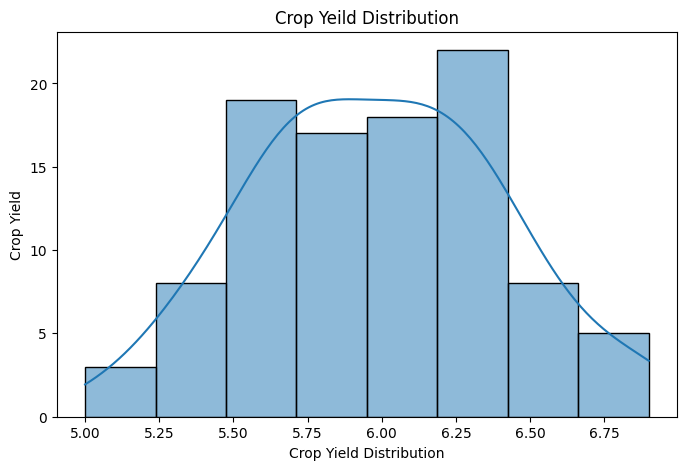

In [28]:
# Step No 6 : Visualization 
# choosing figure size 
plt.figure(figsize=(8,5))

# Creating histplot 
sns.histplot(y , kde=True)

# Creating title 
plt.title("Crop Yeild Distribution")

# Label x - axis 
plt.xlabel("Crop Yield Distribution")

# Label y - axis 
plt.ylabel("Crop Yield")

# Display the plot 
plt.show()

In [29]:
# Step No 7 : Train Test Split 
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size=0.2 , random_state=42)

In [30]:
# Step No 8 : Create Decision Tree Model 
model = DecisionTreeRegressor(max_depth= 5 , random_state=42)

In [31]:
# Step No 9 : Train Model 
model.fit(
    X_train , 
    y_train
)

DecisionTreeRegressor(max_depth=5, random_state=42)

In [32]:
# Step No 10 : Prediction 
y_pred = model.predict(X_test)

# Display predicted values 
print("Predicted Values : ")

print(y_pred)

Predicted Values : 
[6.6        6.4        6.14       5.81428571 5.8        6.81666667
 5.81428571 6.16       5.9        5.67692308 6.4        5.4
 6.2        6.16       6.81666667 5.67692308 5.81428571 5.81428571
 5.5        6.2       ]


In [33]:
# Step No 11 : Evaluation metrics 
# Evaluate MAE metric
print("Mean Absolute Error : ")
print(mean_absolute_error(y_test , y_pred))

# Evaluate MSE metric 
print("Mean Squared Error : ")
print(mean_squared_error(y_test , y_pred ))

# Evalure R2 Score 
print("R2 Score : ")
print(r2_score(y_test , y_pred))


Mean Absolute Error : 
0.19509523809523815
Mean Squared Error : 
0.06576477894510863
R2 Score : 
0.5686848404977298


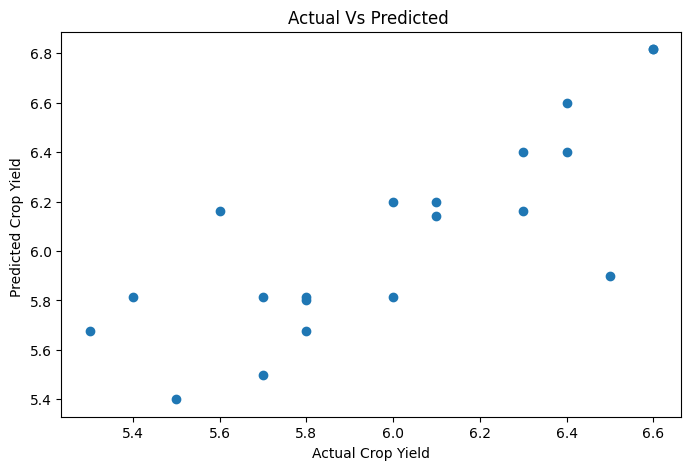

In [34]:
# Step No 12 : Actual Vs Predicted Visualization 
# Choosing figure size 
plt.figure(figsize=(8,5))

# Crate scatter plot 
plt.scatter(y_test , y_pred)

# creating title 
plt.title("Actual Vs Predicted ")


# X - label 
plt.xlabel("Actual Crop Yield")

# y - label 
plt.ylabel("Predicted Crop Yield ")


# Display the plot 
plt.show()

In [35]:
# Step No 13 : Feature Importance 
import pandas as pd
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

print(feature_importance.sort_values(
    by = "Importance",
    ascending= False
))

           Feature  Importance
0         Rainfall    0.617091
3  Fertilizer_Used    0.282425
4         Humidity    0.048919
2          Soil_pH    0.027913
1      Temperature    0.023653


In [36]:
# Step No 14 : User Input 
print(
    "\nEnter Agriculture Information\n"
)

Rainfall = float(input("Rainfall : "))
Temperature = float(input("Temperature : "))
Soil_pH = float(input("Soil Quality : "))
Fertilizer_Used = float(input("Fertilizer Usage : "))
Humidity = float(input(" Humidity : ")) 


Enter Agriculture Information



In [37]:
# Step No 15 : Create User DataFrame 

user_data = pd.DataFrame({
    "Rainfall": [Rainfall],
    "Temperature": [Temperature],
    "Soil_pH": [Soil_pH],
    "Fertilizer_Used": [Fertilizer_Used],
    "Humidity": [Humidity]
})

In [38]:
# Step No 16 : Final Prediction
result = model.predict(user_data)

In [39]:
# Step No 17 : Final Output 
print("Predicted Crop Yield : ", result[0])

Predicted Crop Yield :  5.4
